<a href="https://colab.research.google.com/github/huangfu0411/harry-s-respository/blob/main/chapters/Assignments/A1_Python_and_Pandas_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Python, pandas, and Data That Fights Back


Graded on completion. You may work with others; each of you submits your own copy.

---

**Your name / NYU email: Haoyu Huangfu/hh3170@nyu.edu

**Worked with: Gemini

---

This is the warm-up. It exists because the rest of the term assumes you can get
data into Python and trust what comes out.

**Use AI for all of it.** Every line of code here is something Gemini or ChatGPT
will write for you in seconds, and you should let it. What the AI will *not* do
is notice when the answer is wrong — and this assignment is mostly a tour of
ways a notebook returns a confident, plausible, incorrect number.

Where a question asks you to **predict before running**, do that honestly. The
prediction is the point; getting it wrong costs you nothing.

---

# Part 1 — Two ways a notebook will lie to you

### Q1 — Cells run in the order *you* run them, not the order they appear

Run the next two cells in order. You should get 2,680.19.

In [5]:
deposit = 2000
rate    = 0.05
years   = 6

In [6]:
deposit * (1 + rate) ** years

2680.191281250001

Now, in the cell below, change the rate to **10%** — and do *not* re-run
anything above.

In [3]:
rate = 0.10

Go back and re-run **only** the `deposit * (1 + rate) ** years` cell.

> **(a)** What number do you get now, and why is it not the 5% answer?
>
> **(b)** Now scroll up and re-run the *first* cell, then the calculation cell
> again. What happens, and why?
>
> **(c)** A notebook has an execution *order* and a visual *order*, and they are
> not the same thing. Describe, in one or two sentences, how this could produce a
> number in your final report that you cannot reproduce the next morning.

This is the single most common way a Jupyter result turns out to be wrong, and
AI makes it worse rather than better — pasting a fix halfway up the notebook and
re-running one cell is exactly the move that causes it.

**(a)** 3543.122 bc rate be changed

**(b)** back to 2680.19 bc rate be set up back to 5%

**(c)** the variables in memory depend on the execution order. When you reopen the notebook the next day and run it top-to-bottom (the visual order), those variables will have different values, producing a different final result.

### Q2 — Code that runs, returns a plausible number, and is wrong

You put \$100 into a stock. It returns **+15%** in year one and **−14%** in
year two. The cell below claims to compute what you end up with.

**Do not fix it yet.** First: look at it, and write down what you think it will
print.

In [7]:
r1 = 0.15
r2 = -0.14

100 * 1 + r1 * 1 + r2      # <- what will this print?

100.01

> **(a)** Your prediction, before running:
>
> **(b)** Run it. What did it actually print? Is that number plausible as
> "\$100 after two years"? Would you have caught it if it had appeared in the
> middle of a table?
>
> **(c)** Fix it in the cell below, and state the correct final value.

In [8]:
# Your corrected calculation
100 * (1 + r1) * (1 + r2)

98.89999999999999

**(a)** prediction: 100

**(b)** It printed 100.01. Yes, it is very plausible bc a 15% gain followed by a 14% loss feels like it should be roughly break-even, making it hard to catch if it were buried in a table.

**(c)** correct value: 98.90

---

# Part 2 — Python worth knowing when the AI writes the code

### Q3 — Predict, then run

Below are six statements. `x = 2`, `y = 2`, `z = 4`.

```python
x > z                              # 1
x == y                             # 2
(x < y) and (x > y)                # 3
(x < y) or  (x > y)                # 4
(x <= y) and (x >= y)              # 5
True and ((x < z) or (x < y))      # 6
```

**Write down your six answers first**, as a list like `[True, False, ...]`.
Then run them and compare. Note any you got wrong — `and`/`or` precedence is a
real source of silently wrong filters later in the course.

**My predictions:** `[ , , , , , ]`

In [9]:
x, y, z = 2, 2, 4
# check your six predictions here
[False,True,False,False,True,False ]

[False, True, False, False, True, False]

### Q4 — Data does not arrive as numbers

You are handed a price as `"$6.50"`. Python sees a string, and `"$6.50" * 2`
gives you `"$6.50$6.50"` rather than 13.

Turn it into the float `6.5`. Then say in one sentence what would happen if a
column of a thousand prices had this problem and you took its mean.

In [11]:
price = "$6.50"
# your code here
price_float = float(price.replace('$', ''))
print(price_float)

6.5


**What happens to the mean of a column like this:**
Python cannot do math with text. If you try to find the average of a column of strings, the code will just crash with an error.

### Q5 — Why logs show up everywhere in finance

There is a trick worth knowing: for numbers close to 1, the percent change
$(x-y)/y$ is well approximated by the difference in logs, $\log x - \log y$.

Verify it with the numbers below — compute both and compare. Then try it again
with `x = 2.0, y = 1.0` and report how well the approximation holds.

One sentence: when is it safe to use, and when is it not?

In [12]:
import math

x, y = 1.05, 1.02
# your code here
pct_change_1 = (x - y) / y
log_diff_1 = math.log(x) - math.log(y)
print(f"For x={x}, y={y}:")
print(f"Percent change: {pct_change_1:.5f}")
print(f"Log difference: {log_diff_1:.5f}")

x2, y2 = 2.0, 1.0
pct_change_2 = (x2 - y2) / y2
log_diff_2 = math.log(x2) - math.log(y2)
print(f"\nFor x={x2}, y={y2}:")
print(f"Percent change: {pct_change_2:.5f}")
print(f"Log difference: {log_diff_2:.5f}")

For x=1.05, y=1.02:
Percent change: 0.02941
Log difference: 0.02899

For x=2.0, y=1.0:
Percent change: 1.00000
Log difference: 0.69315


**When it holds, and when it breaks:**
The log approximation is safe when numbers are very close to each other, but it breaks down and becomes highly inaccurate for large jumps.

---

# Part 3 — Real data, which does not want to help you

Everything from here uses one Excel file: 49 US industry portfolios from Ken
French, monthly, going back to 1926, plus a sheet with the market return and the
risk-free rate.

```
https://raw.githubusercontent.com/amoreira2/UG54/refs/heads/main/assets/data/Assignment1.xlsx
```

**Download it and open it in Excel before you write any code.** Ten seconds of
looking will save you an hour. This is a habit, not a suggestion.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 4]

URL = ("https://raw.githubusercontent.com/amoreira2/UG54/"
       "refs/heads/main/assets/data/Assignment1.xlsx")
pd.ExcelFile(URL).sheet_names

['Market_proxy', '49_Industry_Portfolios']

### Q6 — Load it, and count the columns

Read the `49_Industry_Portfolios` sheet. The real column names are **not** in
the first row — there are several lines of description above them, so you will
need `skiprows`.

Then answer this before going further: **how many columns did you get?**

> **(a)** How many columns are there, and how many industries were you promised?
>
> **(b)** Print the column names. Some of them end in `.1` and `.2`. What has
> happened, and what would you have computed if you had just averaged everything?
>
> **(c)** Keep only the block you actually want — the value-weighted returns —
> and say how you know it is the right one.

In [2]:
import pandas as pd

URL = (
    "https://raw.githubusercontent.com/amoreira2/UG54/"
    "refs/heads/main/assets/data/Assignment1.xlsx"
)

# (a) 跳过前6行，让Excel第7行作为列名
raw = pd.read_excel(
    URL,
    sheet_name="49_Industry_Portfolios",
    skiprows=6
)

print("Total columns:", raw.shape[1])
print("Industries promised:", 49)

# (b) 查看全部列名，包括重复名称产生的 .1 和 .2
print("Column names:")
print(raw.columns.tolist())

# (c) 保留第一块：日期 + 49个行业的市值加权月收益率
ind = raw.iloc[:, :50].copy()
ind = ind.rename(columns={ind.columns[0]: "Date"})

print("Selected shape:", ind.shape)
display(ind.head())

Total columns: 152
Industries promised: 49
Column names:
['Unnamed: 0', 'Agric', 'Food', 'Soda', 'Beer', 'Smoke', 'Toys', 'Fun', 'Books', 'Hshld', 'Clths', 'Hlth', 'MedEq', 'Drugs', 'Chems', 'Rubbr', 'Txtls', 'BldMt', 'Cnstr', 'Steel', 'FabPr', 'Mach', 'ElcEq', 'Autos', 'Aero', 'Ships', 'Guns', 'Gold', 'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'PerSv', 'BusSv', 'Hardw', 'Softw', 'Chips', 'LabEq', 'Paper', 'Boxes', 'Trans', 'Whlsl', 'Rtail', 'Meals', 'Banks', 'Insur', 'RlEst', 'Fin', 'Other', 'Unnamed: 50', 'Unnamed: 51', 'Agric.1', 'Food.1', 'Soda.1', 'Beer.1', 'Smoke.1', 'Toys.1', 'Fun.1', 'Books.1', 'Hshld.1', 'Clths.1', 'Hlth.1', 'MedEq.1', 'Drugs.1', 'Chems.1', 'Rubbr.1', 'Txtls.1', 'BldMt.1', 'Cnstr.1', 'Steel.1', 'FabPr.1', 'Mach.1', 'ElcEq.1', 'Autos.1', 'Aero.1', 'Ships.1', 'Guns.1', 'Gold.1', 'Mines.1', 'Coal.1', 'Oil.1', 'Util.1', 'Telcm.1', 'PerSv.1', 'BusSv.1', 'Hardw.1', 'Softw.1', 'Chips.1', 'LabEq.1', 'Paper.1', 'Boxes.1', 'Trans.1', 'Whlsl.1', 'Rtail.1', 'Meals.1', 'Bank

,Date,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
0,192607,2.37,0.12,-99.99,-5.19,1.29,8.65,2.50,50.21,-0.48,...,7.70,1.94,-23.79,0.07,1.87,4.61,-0.54,2.89,-4.85,5.20
1,192608,2.23,2.68,-99.99,27.03,6.50,16.81,-0.76,42.98,-3.58,...,-2.38,4.88,5.39,-0.75,-0.13,11.83,2.57,5.30,-0.57,6.76
2,192609,-0.57,1.58,-99.99,4.02,1.26,8.33,6.42,-4.91,0.73,...,-5.54,0.06,-7.87,0.25,-0.56,-1.75,0.72,-3.06,-3.14,-3.86
3,192610,-0.46,-3.68,-99.99,-3.31,1.06,-1.40,-5.09,5.37,-4.68,...,-5.08,-2.64,-15.38,-2.20,-4.11,-11.82,-4.28,-5.74,2.07,-8.49
4,192611,6.75,6.26,-99.99,7.29,4.55,0.00,1.82,-6.40,-0.54,...,3.84,1.60,4.67,6.52,4.33,-2.97,3.58,2.21,4.92,4.00


**(a)** There are 152 columns, but we were only promised 49 industries.

**(b)** he .1 and .2 suffixes distinguish repeated industry names across different data blocks. Averaging everything would mix returns, firm size, and book-to-market ratios.

**(c)** I kept the first 50 columns: the date and 49 industries. The heading identifies this block as value-weighted monthly returns.

In [15]:
ind = raw.iloc[:, :50]        # date column + the 49 value-weighted industries only
print(ind.shape)

(1064, 50)


### Q7 — Missing values that are not missing

The header text says: *"All missing values are indicated by -99.99 or -999."*

Find them and replace them with proper `NaN`. Then report what fraction of the
table was missing.

> **⚠️** If you skip this, `-99.99` is a perfectly valid number and every mean,
> standard deviation and correlation you compute will quietly include it as a
> **−99.99% monthly return**. Nothing will error.

In [3]:
import numpy as np

# Only count the 49 industry columns, excluding the date
industry_cols = ind.columns[1:]

# Replace the missing-value codes with NaN
ind[industry_cols] = ind[industry_cols].replace(
    [-99.99, -999], np.nan
)

# Calculate the fraction of missing industry returns
missing_count = ind[industry_cols].isna().sum().sum()
total_count = ind[industry_cols].size
fraction_missing = missing_count / total_count

print("Missing values:", missing_count)
print("Total industry observations:", total_count)
print(f"Fraction missing: {fraction_missing:.2%}")

Missing values: 2877
Total industry observations: 52381
Fraction missing: 5.49%


### Q8 — Dates and units

Two more things stand between you and usable data.

**Dates.** The first column is an integer like `192607`. Convert it to a proper
month-end date and make it the index. Month-*end* matters: these are monthly
returns, and later in the course you will merge them against other series that
are stamped at month end. A one-day mismatch silently drops every row.

**Units.** Print the mean of one industry. Is it a monthly return of 0.9%, or
90%? Convert so that a 1% return is stored as `0.01`.

In [4]:
# Convert YYYYMM to month-end dates
ind["Date"] = (
    pd.to_datetime(ind["Date"].astype(str), format="%Y%m")
    + pd.offsets.MonthEnd(0)
)

# Use dates as the index
ind = ind.set_index("Date")

# Check the original units
print(f"Original Agric mean: {ind['Agric'].mean():.5f}%")

# Convert percentage values to decimals
ind = ind / 100

print(f"Agric mean as a decimal: {ind['Agric'].mean():.7f}")
print(f"Agric mean as a percentage: {ind['Agric'].mean():.5%}")
print(ind.index[:3])

Original Agric mean: 0.96393%
Agric mean as a decimal: 0.0096393
Agric mean as a percentage: 0.96393%
DatetimeIndex(['1926-07-31', '1926-08-31', '1926-09-30'], dtype='datetime64[ns]', name='Date', freq=None)


### Q9 — Excess returns

Load the `Market_proxy` sheet the same way — it has `Mkt-RF` and `RF`. Watch the
units here too.

Then build excess returns two ways:

1. For **one** industry, `Agric`, subtract `RF` month by month. Print its mean.
2. For **all 49 at once**, in a single line, producing a DataFrame called `inde`.

> **🤖 Worth asking the AI:** *"subtract a Series from every column of a
> DataFrame, aligning on the index"* — and then check that the row count did not
> change. Getting the axis wrong here produces a table full of NaN, or worse, a
> table that looks fine and is transposed.

In [5]:
# Load market returns and the risk-free rate
market = pd.read_excel(
    URL,
    sheet_name="Market_proxy",
    skiprows=5,
    index_col=0
)

# Convert dates to month-end and percentages to decimals
market.index = (
    pd.to_datetime(market.index.astype(str), format="%Y%m")
    + pd.offsets.MonthEnd(0)
)
market.index.name = "Date"
market = market / 100

# Match the risk-free rate to the industry dates
rf = market["RF"].reindex(ind.index)
assert rf.notna().all(), "Some industry months have no risk-free rate"

# (1) Excess returns for Agric
agric_excess = ind["Agric"] - rf
print(f"Agric mean monthly excess return: {agric_excess.mean():.5%}")

# (2) Excess returns for all 49 industries in one line
inde = ind.sub(rf, axis=0)

# Verify that the row count did not change
print("Rows before:", len(ind))
print("Rows after:", len(inde))

Agric mean monthly excess return: 0.68189%
Rows before: 1069
Rows after: 1069


### Q10 — Dropping rows has a price

Not every industry exists in 1926. To get a rectangular table where every
industry covers the same months, drop the incomplete rows.

Report: how many months you had before, how many after, and **what date the
sample now starts**.

> **(a)** How many months did that cost you?
>
> **(b)** You have just thrown away 40 years of data to keep 49 columns. Name
> one thing you might have done instead, and say what it would have cost.

In [7]:
# your code here
months_before = len(inde)

# Keep only months with data for all 49 industries
inde_complete = inde.dropna()

months_after = len(inde_complete)
months_lost = months_before - months_after

print("Months before:", months_before)
print("Months after:", months_after)
print("Months lost:", months_lost)
print("New start date:", inde_complete.index.min().strftime("%Y-%m-%d"))

Months before: 1069
Months after: 553
Months lost: 516
New start date: 1969-07-31


**(a)** losing 516 months

**(b)** I could drop industries with shorter histories instead. This would preserve more months but reduce industry coverage.

### Q11 — The two objects everything else is built from

Compute and display:

1. `ERe` — the vector of **annualized** mean excess returns, one per industry
2. `CovRe` — the **annualized** covariance matrix of excess returns

> **If you have not met a covariance matrix.** For 49 industries it is a 49×49
> table. The diagonal entry $(i,i)$ is industry $i$'s **variance** — its
> volatility squared. The off-diagonal entry $(i,j)$ is the **covariance**
> between $i$ and $j$: positive when the two tend to move in the same direction,
> negative when one tends to rise as the other falls, near zero when neither
> tells you much about the other.
>
> A **correlation** is that same covariance divided by the two volatilities,
> which rescales it to sit between −1 and +1. Same information, easier to read —
> which is why the question below asks you for correlations rather than raw
> covariances.
>
> `df.cov()` builds the whole table in one call. Nothing in the next few weeks
> needs it. It comes back in Capital Allocation in October, where it is the
> object that decides how much of each thing to hold.

Report the highest and lowest average-return industries. Then print the
correlation between three pairs of your choosing — pick one pair you expect to
move together and one you expect not to, and say whether the data agreed.

Remember: means annualize by ×12, variances by ×12, volatilities by ×√12.

In [8]:
# your code here
# Annualized mean excess returns and covariance matrix
ERe = inde_complete.mean() * 12
CovRe = inde_complete.cov() * 12

print("Annualized mean excess returns:")
display(ERe.to_frame("Annualized mean excess return"))

print("Annualized covariance matrix:")
display(CovRe)

# Highest and lowest annualized mean excess returns
print(f"Highest: {ERe.idxmax()} ({ERe.max():.2%})")
print(f"Lowest: {ERe.idxmin()} ({ERe.min():.2%})")

# Correlations for three industry pairs
pairs = [
    ("Banks", "Fin"),
    ("Gold", "Util"),
    ("Hardw", "Chips")
]

corr = inde_complete.corr()

for a, b in pairs:
    print(f"{a} / {b}: {corr.loc[a, b]:.3f}")

Annualized mean excess returns:


,Annualized mean excess return
Agric,0.071631
Food,0.088494
Soda,0.089709
Beer,0.089444
Smoke,0.128780
Toys,0.044244
Fun,0.108762
Books,0.060896
Hshld,0.055263
Clths,0.082726


Annualized covariance matrix:


,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
Agric,0.050741,0.016674,0.017216,0.018429,0.016790,0.027415,0.030724,0.024782,0.016904,0.026831,...,0.022204,0.026022,0.026006,0.021886,0.026535,0.023817,0.022174,0.030653,0.028147,0.027581
Food,0.016674,0.024780,0.020569,0.019966,0.019868,0.021458,0.023787,0.020112,0.017707,0.022980,...,0.017984,0.019026,0.019493,0.020807,0.022855,0.021178,0.021235,0.022009,0.019307,0.020674
Soda,0.017216,0.020569,0.053268,0.025773,0.020146,0.026898,0.032891,0.025774,0.024083,0.028120,...,0.023632,0.023546,0.024045,0.024566,0.028051,0.027136,0.024909,0.029960,0.025626,0.024935
Beer,0.018429,0.019966,0.025773,0.034099,0.018289,0.024887,0.026951,0.020926,0.021933,0.023354,...,0.018932,0.021325,0.020782,0.022136,0.025286,0.022794,0.021203,0.023533,0.021713,0.024032
Smoke,0.016790,0.019868,0.020146,0.018289,0.047087,0.020389,0.021975,0.017015,0.017522,0.018997,...,0.018302,0.016397,0.019966,0.016911,0.020126,0.019398,0.018387,0.019251,0.017664,0.021679
Toys,0.027415,0.021458,0.026898,0.024887,0.020389,0.061461,0.047371,0.034650,0.026711,0.040982,...,0.031669,0.037127,0.035309,0.033893,0.039558,0.032098,0.029392,0.043842,0.035728,0.037064
Fun,0.030724,0.023787,0.032891,0.026951,0.021975,0.047371,0.074032,0.041335,0.028930,0.045200,...,0.033508,0.038056,0.040047,0.037004,0.043954,0.038116,0.033698,0.051072,0.042999,0.042241
Books,0.024782,0.020112,0.025774,0.020926,0.017015,0.034650,0.041335,0.042509,0.023298,0.036000,...,0.027013,0.030731,0.031419,0.031235,0.032016,0.031503,0.029338,0.040689,0.033880,0.032984
Hshld,0.016904,0.017707,0.024083,0.021933,0.017522,0.026711,0.028930,0.023298,0.027420,0.024193,...,0.021751,0.022932,0.021795,0.022733,0.025943,0.023704,0.021494,0.024111,0.023147,0.025151
Clths,0.026831,0.022980,0.028120,0.023354,0.018997,0.040982,0.045200,0.036000,0.024193,0.054862,...,0.029498,0.035526,0.034177,0.037588,0.038179,0.033976,0.031001,0.044931,0.036001,0.036625


Highest: Smoke (12.88%)
Lowest: Other (0.86%)
Banks / Fin: 0.796
Gold / Util: 0.169
Hardw / Chips: 0.835


**Pairs I picked, what I expected, what I found:** I picked Banks/Fin, Gold/Util, and Hardw/Chips. I expected Banks/Fin 0.85 and Hardw/Chips 0.75 to be strongly correlated, and Gold/Util 0.12 to be weakly correlated. Finially the result shows 0.796, 0.835, 0.169 respectively, which supported my expectations.

### Q12 — Look at it

Pick **two** industries that you think behaved very differently in some
identifiable episode — a crisis, a boom, a technological shift.

1. Plot their monthly excess returns over that period.
2. Plot the **cumulative** return of \$1 invested in each over that period.
3. In three or four sentences, say what happened, using the actual magnitudes
   from your plot. What would \$1 have become in each?

> **📌** Cumulative returns compound: `(1 + r).cumprod()`, not `r.cumsum()`.
> Adding returns is Lecture 1's pitfall 4 and the error grows with horizon.

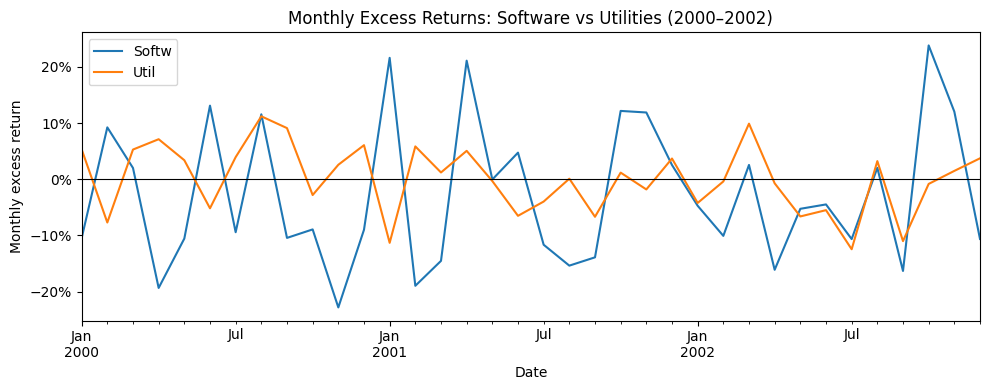

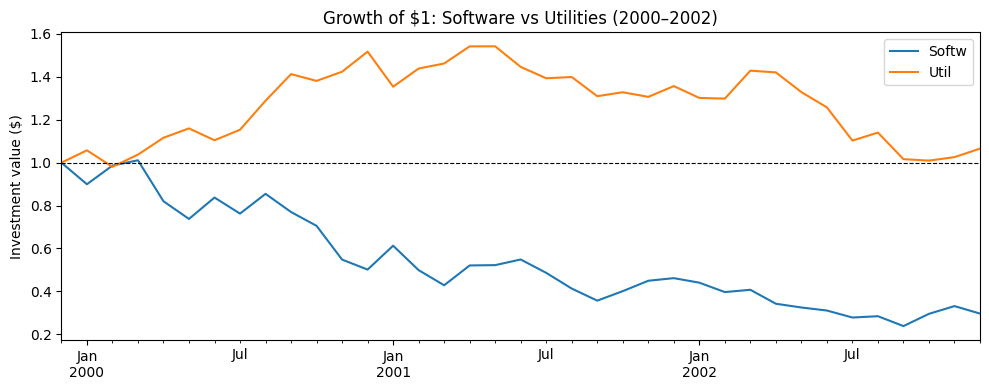

Softw: $1 became $0.297; cumulative return = -70.33%
Util: $1 became $1.065; cumulative return = 6.53%


In [9]:
# your code here
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Select two industries during the dot-com bust
industries = ["Softw", "Util"]
returns = ind.loc["2000":"2002", industries]
excess = inde_complete.loc["2000":"2002", industries]

# 1. Monthly excess returns
ax = excess.plot(
    figsize=(10, 4),
    title="Monthly Excess Returns: Software vs Utilities (2000–2002)"
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Monthly excess return")
ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.tight_layout()
plt.show()

# 2. Growth of $1 using total returns
wealth = (1 + returns).cumprod()

# Add the initial $1 before the first month's return
initial = pd.DataFrame(
    [[1.0, 1.0]],
    index=[returns.index[0] - pd.offsets.MonthEnd(1)],
    columns=industries
)
wealth_plot = pd.concat([initial, wealth])

ax = wealth_plot.plot(
    figsize=(10, 4),
    title="Growth of $1: Software vs Utilities (2000–2002)"
)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Investment value ($)")
plt.tight_layout()
plt.show()

# Print the actual ending values and cumulative returns
for industry in industries:
    ending = wealth[industry].iloc[-1]
    print(
        f"{industry}: $1 became ${ending:.3f}; "
        f"cumulative return = {ending - 1:.2%}"
    )

**What happened:**  From January 2000 through December 2002, software substantially underperformed utilities during the dot-com bust. A $1 investment at the beginning of this period fell to about $0.297 in software, a cumulative loss of 70.33%. In contrast, $1 invested in utilities grew to about $1.065, a cumulative gain of 6.53%. Software’s monthly excess returns ranged from −22.81% to 23.84%, compared with −12.45% to 11.22% for utilities, showing more extreme monthly swings.

---

## 📤 Submission

1. **Run your notebook from a clean start** — Runtime → Restart and run all.
   If it does not survive that, Q1 is still ahead of you.
2. File → Download → `.ipynb`
3. Upload to Brightspace under Assignment 1.

---

## What this was for

Next week you meet a dataset with 1.5 million rows where you cannot open the
file and look. Every trap in Part 3 is one you will hit again there, invisibly:
columns that are not what they claim, sentinel values masquerading as data,
dates that do not line up, and percent where you assumed decimal.

You will also notice that this file is **wide** — one column per industry. The
course panel is **long** — one row per stock-month. Lecture 2 explains why, and
having built something in the wide shape first is the point.